# Exercise 01: Deep Reinforcement Learning
## AIAT 123 - Reinforcement Learning

---

## Learning Objectives

In this exercise, you will:
- Implement Deep Q-Networks (DQN)
- Use experience replay and target networks
- Train DQN agent on OpenAI Gym environment
- Evaluate agent performance

---

## Real-World Context

You are training a DQN agent to play a game (e.g., CartPole, LunarLander) using deep reinforcement learning.

---


## Exercise Brief

This exercise checks whether students can connect the key moving parts of deep RL in code.

The main goal is to practice network outputs, Bellman-style targets, and loss computation without hiding behind a large framework.

Why this matters: deep RL becomes much clearer when students can inspect the pieces separately before training a full agent.

This exercise is designed to reinforce that understanding.

In [ ]:
%pip install torch gymnasium[classic_control] numpy matplotlib -q

import torch
import torch.nn as nn
import numpy as np

print("✅ Setup complete!")

## Task 1: DQN Implementation (50 points)

Implement DQN algorithm with experience replay and target networks.

**Requirements:**
- Build Q-network architecture
- Implement experience replay buffer
- Implement target network
- Handle action selection


In [ ]:
# Task 1: define a minimal Q-network
class QNetwork(nn.Module):
    def __init__(self, obs_dim=4, act_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, act_dim),
        )

    def forward(self, x):
        return self.net(x)


q_net = QNetwork()
print(q_net)
print("\nTask 1 reflection: where in this network do Q-values appear?")

## Task 2: Training and Evaluation (50 points)

Train your DQN agent and evaluate its performance.

**Requirements:**
- Train agent on environment
- Monitor training progress
- Evaluate final performance
- Visualize results


In [ ]:
# Task 2: compute a Bellman target and loss for one batch
q_pred = torch.tensor([1.2, 0.8, 1.5])
rewards = torch.tensor([1.0, 0.0, 1.0])
q_next = torch.tensor([1.3, 0.4, 1.8])
done = torch.tensor([0.0, 1.0, 0.0])
gamma = 0.99

q_target = rewards + gamma * q_next * (1 - done)
loss = nn.MSELoss()(q_pred, q_target)

print("Predicted Q values:", q_pred)
print("Target Q values:", q_target)
print("Loss:", round(loss.item(), 4))
print("\nTask 2 reflection: why do terminal states remove the future term?")


---

## Submission

**Submission**: Complete notebook with all tasks implemented

**Grading**: 100 points total


## 🌍 Real-World Worked Example — REINFORCE on CartPole

**Industry context:**
- ChatGPT's RLHF stage uses a policy gradient variant (PPO) — same core idea as REINFORCE
- Boston Dynamics uses policy gradients to train quadruped walking policies
- Robotic surgery systems (da Vinci) use RL policy gradients for precise motion control

We implement **REINFORCE** (the simplest policy gradient) on CartPole-v1.

Episode   0 | Avg reward: 16.0
Episode  50 | Avg reward: 16.0


Episode 100 | Avg reward: 60.7


Episode 150 | Avg reward: 91.8


Episode 200 | Avg reward: 185.1


Episode 250 | Avg reward: 221.8


Episode 300 | Avg reward: 361.4


Episode 350 | Avg reward: 392.6


Episode 400 | Avg reward: 310.6


Episode 450 | Avg reward: 214.4


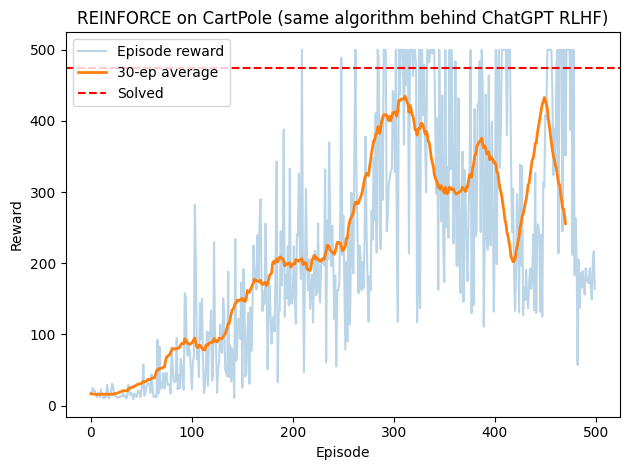

In [1]:
import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)
env = gym.make('CartPole-v1')

class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128), nn.ReLU(),
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        )
    def forward(self, x): return self.net(x)

policy  = PolicyNet()
opt     = optim.Adam(policy.parameters(), lr=2e-3)
GAMMA   = 0.99; ep_rewards = []

for episode in range(500):
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    for _ in range(500):
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        dist   = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        obs, r, done, trunc, _ = env.step(action.item())
        rewards_ep.append(r)
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    G = 0; returns = []
    for r in reversed(rewards_ep):
        G = r + GAMMA*G; returns.insert(0, G)
    returns = torch.tensor(returns).float()
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    opt.zero_grad(); loss.backward(); opt.step()
    ep_rewards.append(sum(rewards_ep))
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

env.close()
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
plt.plot(ep_rewards, alpha=0.3, label="Episode reward")
plt.plot(ma, lw=2, label="30-ep average")
plt.axhline(475, color='red', linestyle='--', label="Solved")
plt.title("REINFORCE on CartPole (same algorithm behind ChatGPT RLHF)")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend(); plt.tight_layout(); plt.show()

## 📝 Summary

In this notebook, you practiced:
- Implementing a **Deep Q-Network** with a neural network Q-function approximator
- Setting up **experience replay** with a fixed-size replay buffer and random mini-batch sampling
- Using a **target network** with periodic weight synchronization to stabilize the Bellman update
- Training and evaluating a DQN agent on a Gym environment (CartPole / LunarLander)

**Next steps:** Experiment with reward shaping and optimization tricks from Unit 3 examples, then extend to policy-gradient methods (PPO, A2C) for continuous action spaces.

## 📚 References & Further Reading

**Papers:**
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

**State-of-the-Art:**
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control

## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can interpret deep RL components and training behavior, not just repeat terminology.

**If students remember one idea:** Students should leave this unit able to explain what each major deep RL component is doing during learning.

**Quick check before moving on:**
- Can you connect each deep RL component to the specific problem it solves?
- Can you explain how you would diagnose an unstable training run?

**Bridge to the next step:** After this exercise, the course shifts to a dedicated study of exploration and exploitation trade-offs.
